In [1]:
import os
import torch
import numpy as np
from astropy.table import Table as aT

from sedflow import flows as F

In [2]:
import corner as DFM
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rcParams['text.usetex'] = True
#mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [3]:
if torch.cuda.is_available(): device = 'cuda'
else: device = 'cpu'

# import flows
desiflow = F.DESIflow(name='modelb.lowz.grzW1W2', device=device)

In [4]:
lrgs = aT.read('/tigress/chhahn/sedflow/overlapping_catalog_legacy_info_100.txt', format='ascii')

# 1. correct for extinction
flux_g = lrgs['col5'] / lrgs['col10']
flux_r = lrgs['col6'] / lrgs['col11']
flux_z = lrgs['col7'] / lrgs['col12']
flux_w1 = lrgs['col8'] / lrgs['col13']
flux_w2 = lrgs['col9'] / lrgs['col14']

fluxes = np.array([flux_g, flux_r, flux_z, flux_w1, flux_w2]).T

# 2. compile other measurements
sig_g  = lrgs['col15']**-0.5
sig_r  = lrgs['col16']**-0.5
sig_z  = lrgs['col17']**-0.5
sig_w1 = lrgs['col18']**-0.5
sig_w2 = lrgs['col19']**-0.5

sig_fluxes = np.array([sig_g, sig_r, sig_z, sig_w1, sig_w2]).T

redshift = lrgs['col4']

In [5]:
igal = 0
posterior_samples, log_prob = desiflow.run(
    fluxes[igal],           # flux in nmgy
    sig_fluxes[igal],       # sigma in nmgy
    redshift[igal],         # redshift
    Nsample=10000,       # number of samples
    log_prob=True,
    progress_bar=True)

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

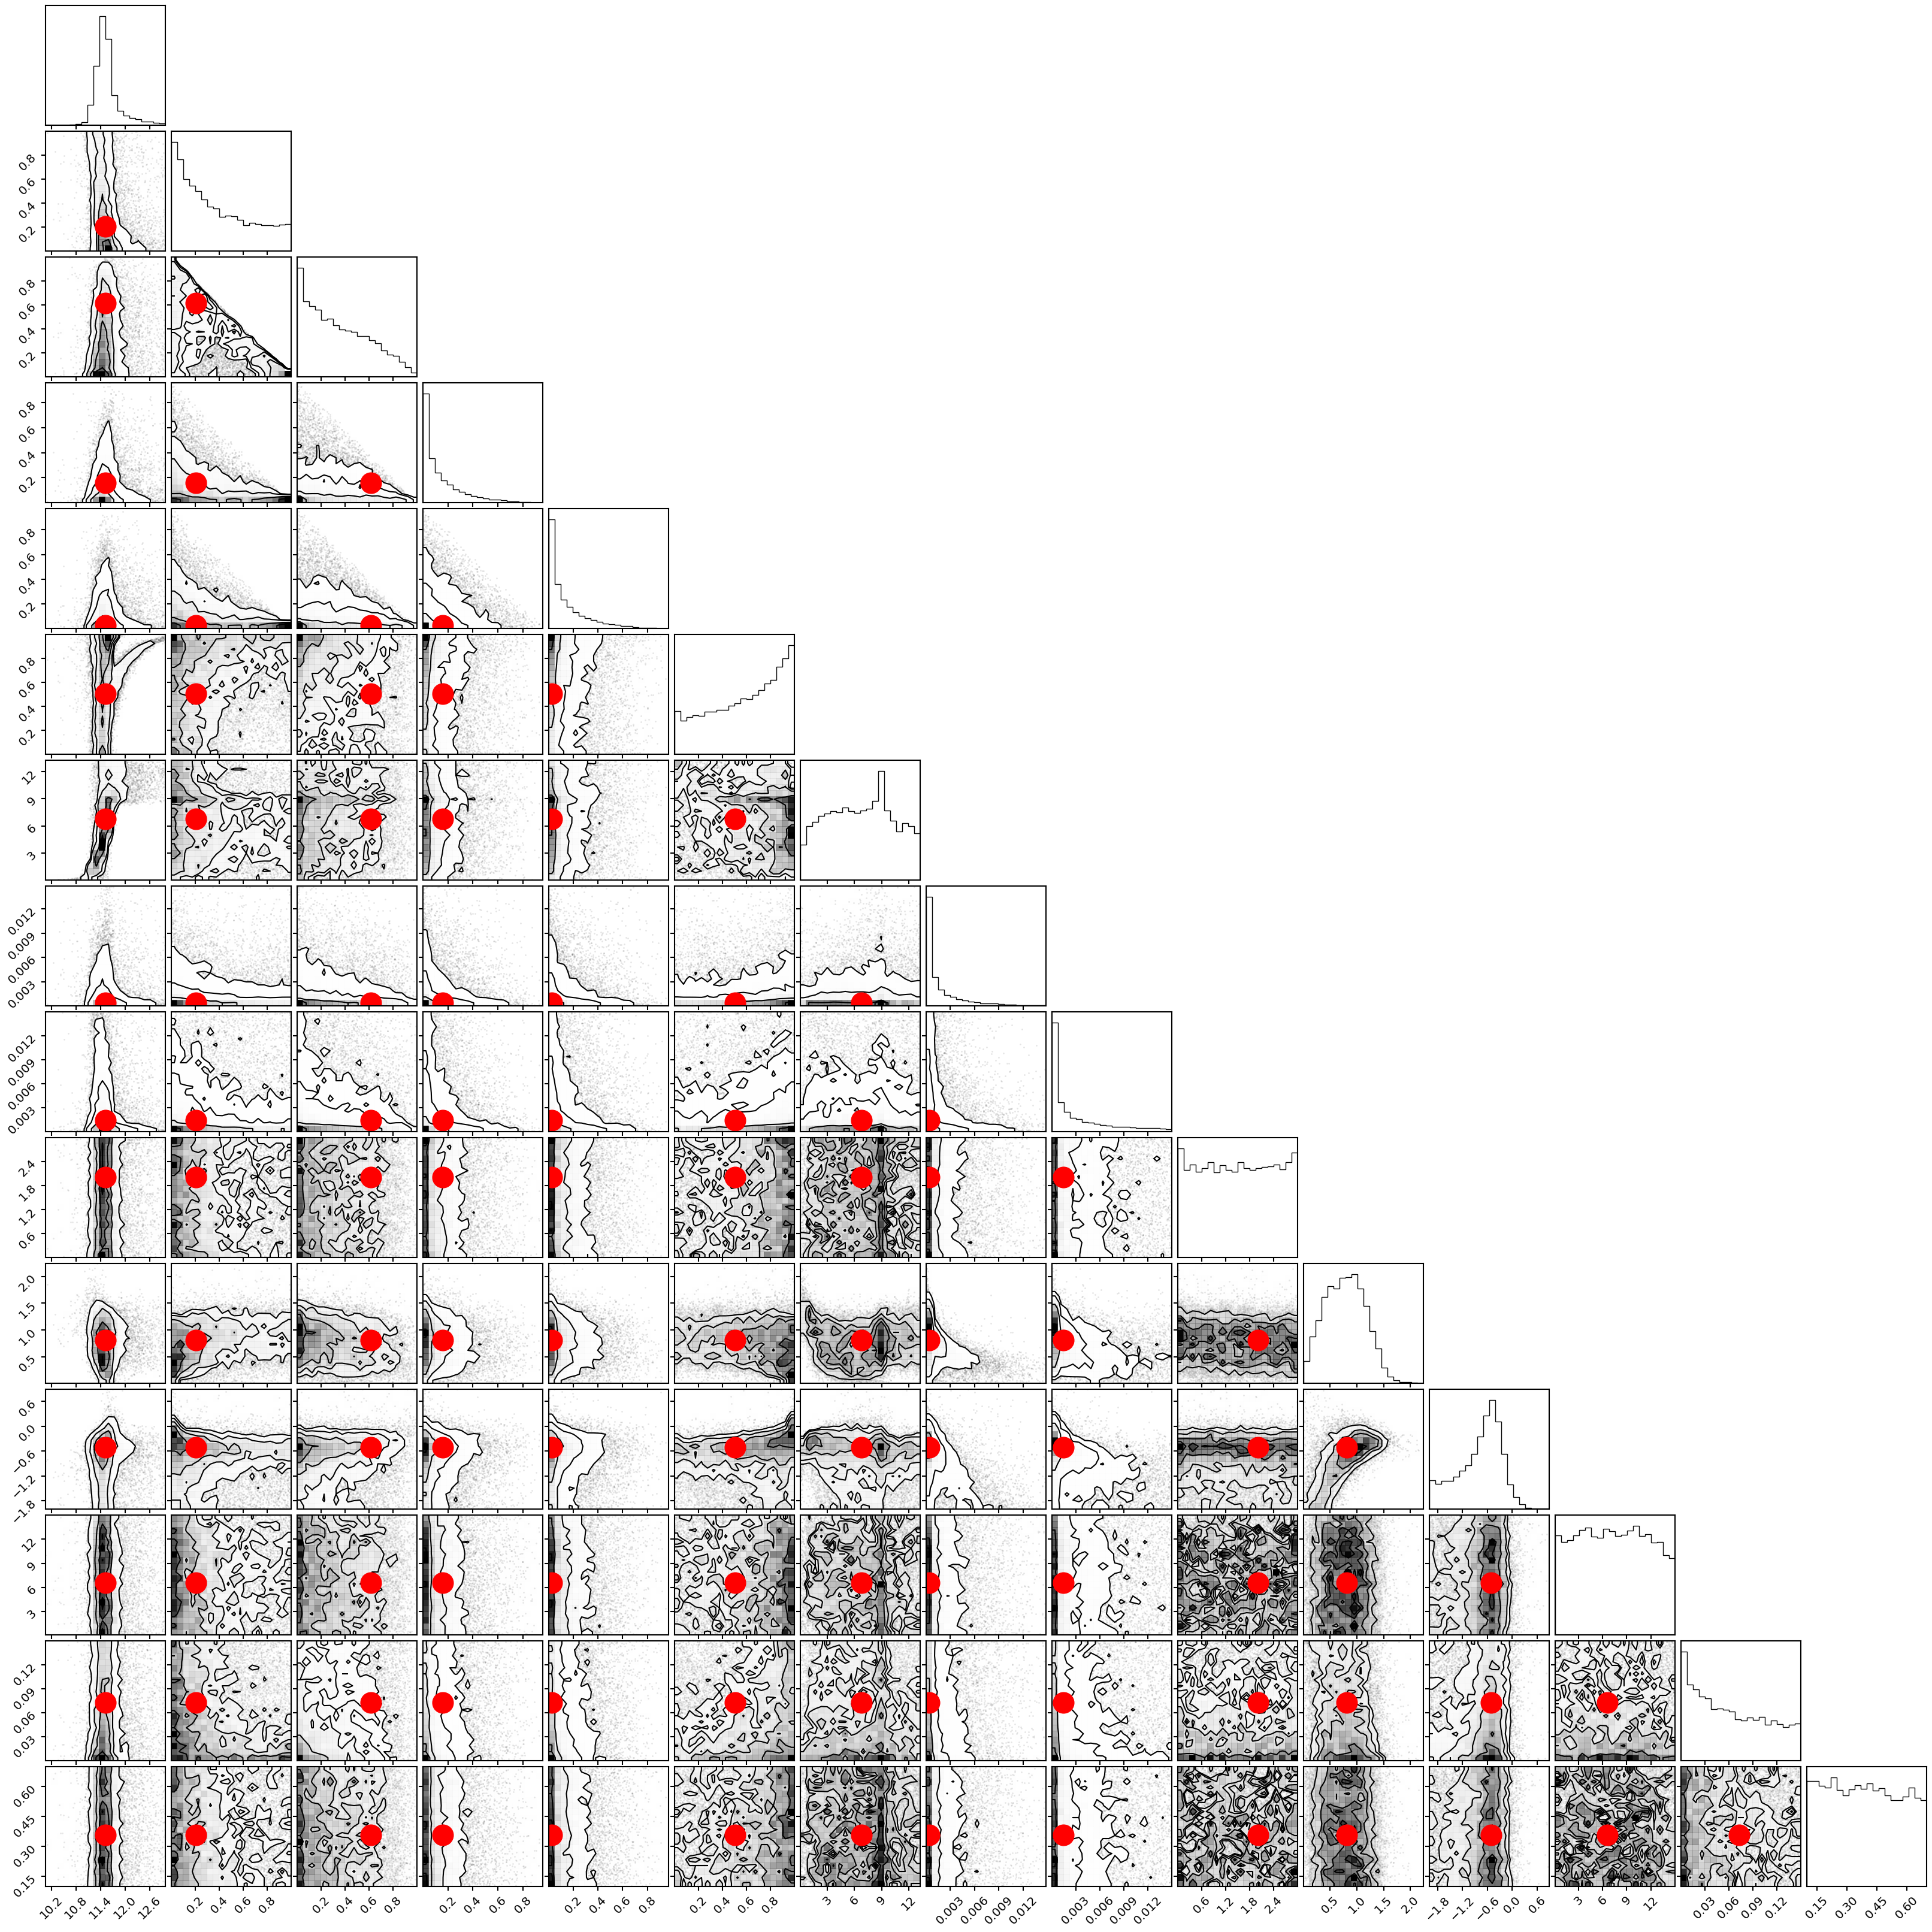

In [10]:
fig = DFM.corner(posterior_samples)
DFM.overplot_points(fig, [posterior_samples[np.argmax(log_prob)]], color='r', markersize=50)